Importing

Importing csv as pandas dataframe.

In [171]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

df = pd.read_csv("diabetes_dataset.csv")

Parsing

Because there are no missing values, we do not need to handle them.

We believe that there are boundary conditions for the  Ldl Cholesterol and Insulin Level categories. 

In [172]:
# dropping all samples where Ldl Cholesterol is equal to 50

display(df[df['ldl_cholesterol'] == 50]['ldl_cholesterol'].value_counts(),
df[df['ldl_cholesterol'] == 51]['ldl_cholesterol'].value_counts(),
df[df['ldl_cholesterol'] == 52]['ldl_cholesterol'].value_counts(),
df[df['ldl_cholesterol'] == 53]['ldl_cholesterol'].value_counts(),
df[df['ldl_cholesterol'] == 54]['ldl_cholesterol'].value_counts())

df = df[df['ldl_cholesterol'] > 50]
display(df[df['ldl_cholesterol'] == 50]['ldl_cholesterol'].value_counts())

ldl_cholesterol
50    7430
Name: count, dtype: int64

ldl_cholesterol
51    358
Name: count, dtype: int64

ldl_cholesterol
52    435
Name: count, dtype: int64

ldl_cholesterol
53    448
Name: count, dtype: int64

ldl_cholesterol
54    464
Name: count, dtype: int64

Series([], Name: count, dtype: int64)

In [173]:
# dropping all samples where Insulin Level is equal to 50

display(df[df['insulin_level'] == 2]['insulin_level'].value_counts(),
df[df['insulin_level'] == 3]['insulin_level'].value_counts(),
df[df['insulin_level'] == 4]['insulin_level'].value_counts(),
df[df['insulin_level'] == 5]['insulin_level'].value_counts(),
df[df['insulin_level'] == 6]['insulin_level'].value_counts())

df = df[df['insulin_level'] > 2]
display(df[df['insulin_level'] == 50]['insulin_level'].value_counts())

insulin_level
2.0    9532
Name: count, dtype: int64

insulin_level
3.0    40
Name: count, dtype: int64

insulin_level
4.0    49
Name: count, dtype: int64

insulin_level
5.0    53
Name: count, dtype: int64

insulin_level
6.0    61
Name: count, dtype: int64

Series([], Name: count, dtype: int64)

Organizing

We are choosing which columns to use and cleaning these columns.

Columns we are dropping: diagnosed_diabetes


In [174]:
diabetes_stage_detectors_df = list(df.groupby('diabetes_stage')[['ldl_cholesterol', 'insulin_level', 'hba1c', 'waist_to_hip_ratio']])

smoking_df = df[['smoking_status', 'diabetes_stage']]

df3s = list(df.groupby('diagnosed_diabetes')[['diet_score']])

Test1

Doing consecutive ANOVA tests to see if any diabetes stages have an effect on the following values: ldl cholesterol, insulin levle, hba1c, and waist to hip ratio.

In [175]:
# storing dataframes by diabetes stage
gestational = diabetes_stage_detectors_df[0][1]
no_diabetes = diabetes_stage_detectors_df[1][1]
pre_diabetes = diabetes_stage_detectors_df[2][1]
type1 = diabetes_stage_detectors_df[3][1]
type2 = diabetes_stage_detectors_df[4][1]


Testing ldl cholesterol:

H0 = Diabetes Stage has no effect on ldl cholesterol values

HA = Diabetes Stage has a significant effect on ldl cholesterol values

3.21445396143435e-81

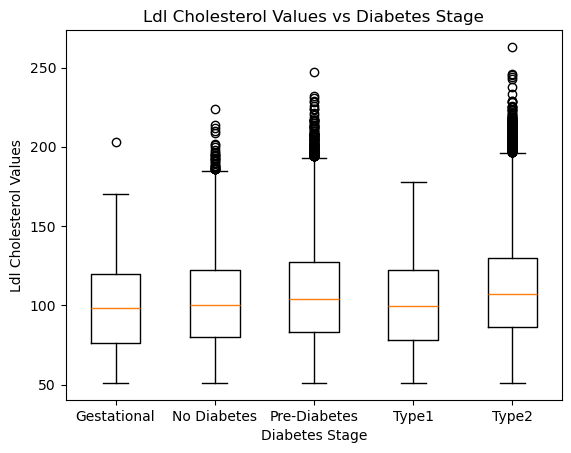

In [176]:
ldl_gestational = gestational['ldl_cholesterol']
ldl_no_diabetes = no_diabetes['ldl_cholesterol']
ldl_pre_diabetes = pre_diabetes['ldl_cholesterol']
ldl_type1 = type1['ldl_cholesterol']
ldl_type2 = type2['ldl_cholesterol']

# Chose ANOVA as there are 3 groups of independent data that we are comparing
# the means of to see if there is any significant difference
res = stats.f_oneway(ldl_gestational, ldl_no_diabetes, ldl_pre_diabetes, ldl_type1, ldl_type2)
display(res.pvalue.item())

plt.boxplot([ldl_gestational, ldl_no_diabetes, ldl_pre_diabetes, ldl_type1, ldl_type2], tick_labels=["Gestational", "No Diabetes", "Pre-Diabetes", "Type1", "Type2"])

# plt.legend()
plt.title("Ldl Cholesterol Values vs Diabetes Stage")
plt.xlabel("Diabetes Stage")
plt.ylabel("Ldl Cholesterol Values")
plt.show()

We note the excessive circles representing outliers. We propose that the cause of so many outliers is due to the large sample size. This occurs throughout all four categories we chose. 

Since our p-value is 3.21445396143435e-81, which is less than our α = 0.05, we reject the null hypothesis and conclude that at least one of the diabetes stages has different Ldl Cholesterol values than the others.

0        160
2         99
3         79
4        125
7        159
        ... 
99990     90
99991     97
99992    140
99993    109
99994     57
Name: ldl_cholesterol, Length: 50520, dtype: int64

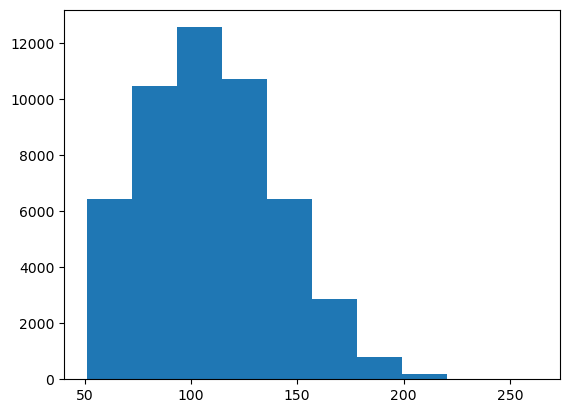

In [177]:
display(ldl_type2)
plt.hist(ldl_type2)
plt.show()

Testing insulin level:

H0 = Diabetes Stage has no effect on insulin level values

HA = Diabetes Stage has a significant effect on insulin level values

6.252306847369782e-48

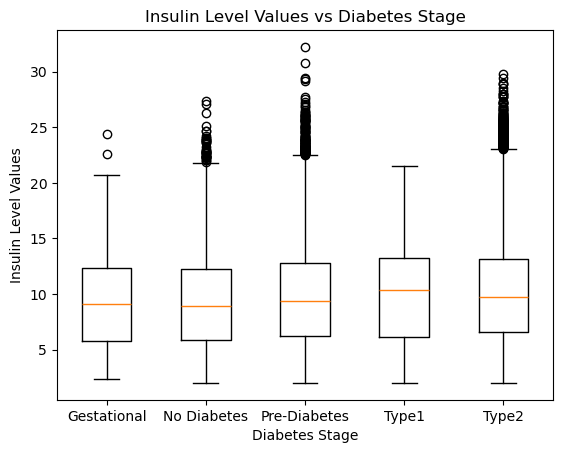

In [178]:
insulin_gestational = gestational['insulin_level']
insulin_no_diabetes = no_diabetes['insulin_level']
insulin_pre_diabetes = pre_diabetes['insulin_level']
insulin_type1 = type1['insulin_level']
insulin_type2 = type2['insulin_level']

# Chose ANOVA as there are 3 groups of independent data that we are comparing
# the means of to see if there is any significant difference
res = stats.f_oneway(insulin_gestational, insulin_no_diabetes, insulin_pre_diabetes, insulin_type1, insulin_type2)
display(res.pvalue.item())

plt.boxplot([insulin_gestational, insulin_no_diabetes, insulin_pre_diabetes, insulin_type1, insulin_type2], tick_labels=["Gestational", "No Diabetes", "Pre-Diabetes", "Type1", "Type2"])

# plt.legend()
plt.title("Insulin Level Values vs Diabetes Stage")
plt.xlabel("Diabetes Stage")
plt.ylabel("Insulin Level Values")
plt.show()

Since our p-value is 6.252306847369782e-48, which is less than our α = 0.05, we reject the null hypothesis and conclude that at least one of the diabetes stages has different Insulin Level values than the others.

Testing hba1c:

H0 = Diabetes Stage has no effect on hba1c values

HA = Diabetes Stage has a significant effect on hba1c values

0.0

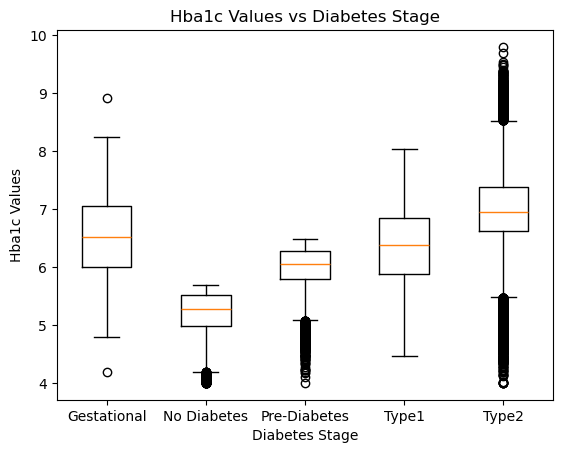

In [179]:
hba1c_gestational = gestational['hba1c']
hba1c_no_diabetes = no_diabetes['hba1c']
hba1c_pre_diabetes = pre_diabetes['hba1c']
hba1c_type1 = type1['hba1c']
hba1c_type2 = type2['hba1c']

# Chose ANOVA as there are 3 groups of independent data that we are comparing
# the means of to see if there is any significant difference
res = stats.f_oneway(hba1c_gestational, hba1c_no_diabetes, hba1c_pre_diabetes, hba1c_type1, hba1c_type2)
display(res.pvalue.item())

plt.boxplot([hba1c_gestational, hba1c_no_diabetes, hba1c_pre_diabetes, hba1c_type1, hba1c_type2], tick_labels=["Gestational", "No Diabetes", "Pre-Diabetes", "Type1", "Type2"])

# plt.legend()
plt.title("Hba1c Values vs Diabetes Stage")
plt.xlabel("Diabetes Stage")
plt.ylabel("Hba1c Values")
plt.show()

Since our p-value is 0.0, which is less than our α = 0.05, we reject the null hypothesis and conclude that at least one of the diabetes stages has different Hba1c values than the others.

Testing waist to hip ratio:

H0 = Diabetes Stage has no effect on waist to hip ratio values

HA = Diabetes Stage has a significant effect on waist to hip ratio values

5.013627270090914e-116

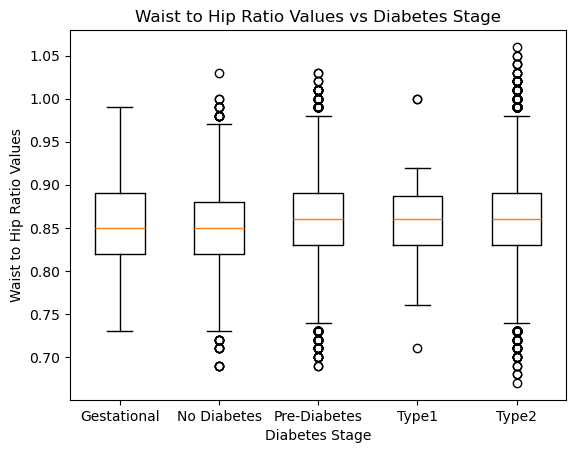

In [180]:
whr_gestational = gestational['waist_to_hip_ratio']
whr_no_diabetes = no_diabetes['waist_to_hip_ratio']
whr_pre_diabetes = pre_diabetes['waist_to_hip_ratio']
whr_type1 = type1['waist_to_hip_ratio']
whr_type2 = type2['waist_to_hip_ratio']

# Chose ANOVA as there are 3 groups of independent data that we are comparing
# the means of to see if there is any significant difference
res = stats.f_oneway(whr_gestational, whr_no_diabetes, whr_pre_diabetes, whr_type1, whr_type2)
display(res.pvalue.item())

plt.boxplot([whr_gestational, whr_no_diabetes, whr_pre_diabetes, whr_type1, whr_type2], tick_labels=["Gestational", "No Diabetes", "Pre-Diabetes", "Type1", "Type2"])

# plt.legend()
plt.title("Waist to Hip Ratio Values vs Diabetes Stage")
plt.xlabel("Diabetes Stage")
plt.ylabel("Waist to Hip Ratio Values")
plt.show()

Since our p-value is 5.013627270090914e-116, which is less than our α = 0.05, we reject the null hypothesis and conclude that at least one of the diabetes stages has different Waist to Hip Ratio values than the others.

Since all of these categories have significant p-values, we will perform a post hoc test on all categories.

In [181]:
res = stats.tukey_hsd(ldl_gestational, ldl_no_diabetes, ldl_pre_diabetes, ldl_type1, ldl_type2)
print(res)

res = stats.tukey_hsd(insulin_gestational, insulin_no_diabetes, insulin_pre_diabetes, insulin_type1, insulin_type2)
print(res)

res = stats.tukey_hsd(hba1c_gestational, hba1c_no_diabetes, hba1c_pre_diabetes, hba1c_type1, hba1c_type2)
print(res)

res = stats.tukey_hsd(whr_gestational, whr_no_diabetes, whr_pre_diabetes, whr_type1, whr_type2)
print(res)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -2.333     0.812    -8.172     3.507
 (0 - 2)     -5.676     0.056   -11.441     0.088
 (0 - 3)     -0.389     1.000   -10.991    10.213
 (0 - 4)     -8.905     0.000   -14.658    -3.153
 (1 - 0)      2.333     0.812    -3.507     8.172
 (1 - 2)     -3.344     0.000    -4.539    -2.149
 (1 - 3)      1.944     0.977    -7.034    10.922
 (1 - 4)     -6.573     0.000    -7.711    -5.435
 (2 - 0)      5.676     0.056    -0.088    11.441
 (2 - 1)      3.344     0.000     2.149     4.539
 (2 - 3)      5.287     0.487    -3.641    14.216
 (2 - 4)     -3.229     0.000    -3.874    -2.584
 (3 - 0)      0.389     1.000   -10.213    10.991
 (3 - 1)     -1.944     0.977   -10.922     7.034
 (3 - 2)     -5.287     0.487   -14.216     3.641
 (3 - 4)     -8.516     0.070   -17.438     0.405
 (4 - 0)      8.905     0.000     3.153    14.658
 (4 - 1)      6.573     0.000     5.435     

Post Hoc Analysis

The one with the CLEAREST distinction is hba1c, as all categories EXCEPT Gestational vs Type 1 have significant p values.
This means:
> The Diabetes Stage has a significant effect on hba1c (except between Gestational Diabetes and Type 1 Diabetes)
> So hba1c is not significantly different between Gestational and Type 1 diabetes, and should not be used when trying to decide between Gestational and Type 1

Ldl Cholesterol is a close second, but it has a hard time with all Type 1s, which after looking at the box plot for ldl Cholesterol, type 1 diabetes box + whiskers overlaps with all the other diabetes labels. All the other boxes and whiskers have some distinction (larger range/Q3), so they have some significant differences (which reflect in their p-values).

Waist to hip ratio has no-diabetes as an outlier (except with type 1, autoimmune diabetes), so may be used as an initial test to see if ANY diabetes is detected.

Insulin has a significant difference between no-diabetes, pre-diabetes, and type 2. This means that insulin may be used for testing following the development of metabolic diabetes.

Test 2

Performing a chi-squared between Smoking Status and Diabetes Stage to determine if these two categories are independent.

H0: Smoking status does not have an effect on diabetes stage.

HA: Smoking status has an effect on diabetes stage.

0.8889454761878

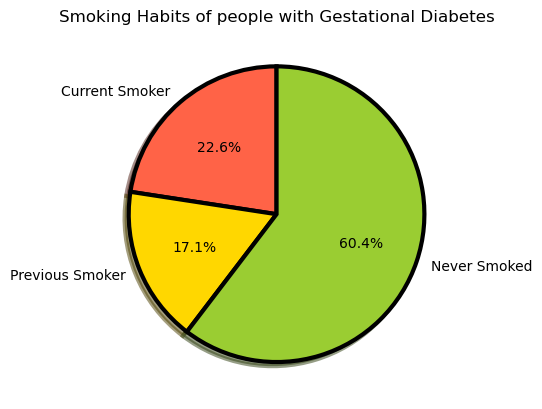

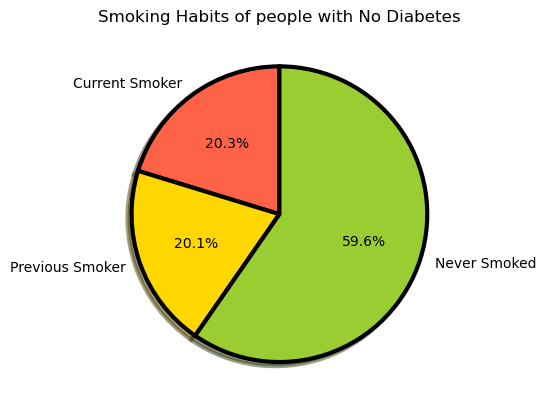

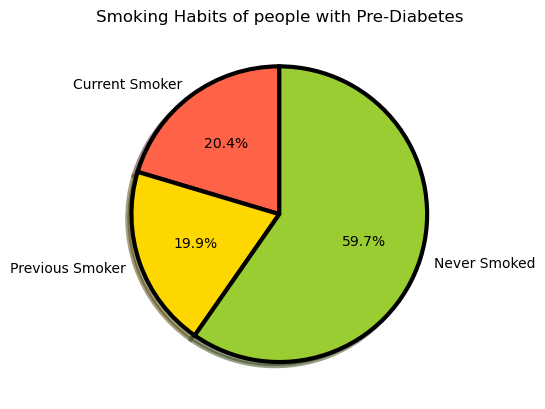

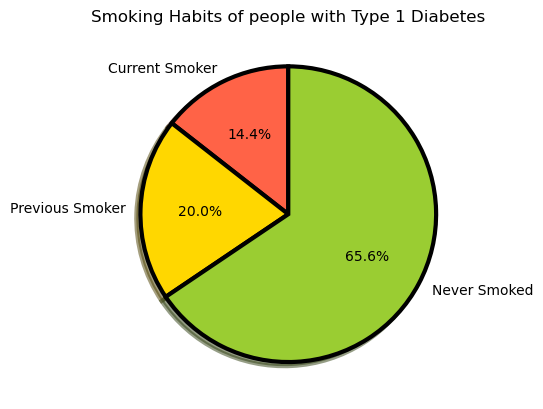

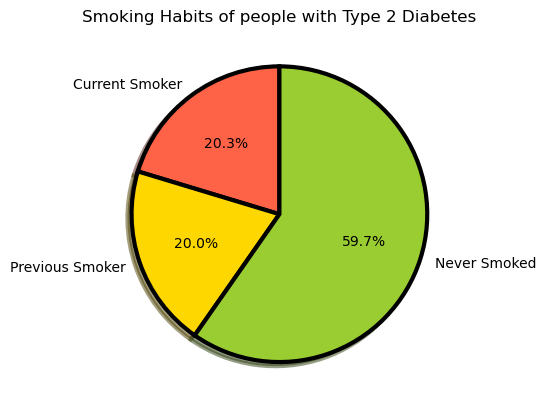

In [ ]:
type_1_ldl_cholesterol = type1['ldl_cholesterol']

df2 = df[['smoking_status', 'diabetes_stage']]

ctable = pd.crosstab(df['smoking_status'], df['diabetes_stage'])
s, pval, dof, expected = stats.chi2_contingency(ctable)
display(pval.item())

# plot1 = ctable['Gestational']
# plot2 = ctable['No Diabetes']
# plot3 = ctable['Pre-Diabetes']
# plot4 = ctable['Type 1']
# plot5 = ctable['Type 2']

# f1 = plt.figure(1)
# plt.pie(plot1)
# f2 = plt.figure(2)
# plt.pie(plot2)
# f3 = plt.figure(3)
# plt.pie(plot3)
# f4 = plt.figure(4)
# plt.pie(plot4)
# f5 = plt.figure(5)
# plt.pie(plot5)
labels = ['Current Smoker', 'Previous Smoker', 'Never Smoked']
plot1 = ctable['Gestational']
plot2 = ctable['No Diabetes']
plot3 = ctable['Pre-Diabetes']
plot4 = ctable['Type 1']
plot5 = ctable['Type 2']

plots = [plot1, plot2, plot3, plot4, plot5]


titles = ['Smoking Habits of people with Gestational Diabetes',
'Smoking Habits of people with No Diabetes',
'Smoking Habits of people with Pre-Diabetes',
'Smoking Habits of people with Type 1 Diabetes',
'Smoking Habits of people with Type 2 Diabetes']

i = 0
for plot in plots:
    fig, ax = plt.subplots()
    ax.pie(plot, labels=labels, autopct='%1.1f%%', colors=['tomato', 
        'gold', 'yellowgreen'], shadow = True, 
        startangle = 90, wedgeprops= {"edgecolor":"black",
            'linewidth': 3,
            'antialiased': True})
    ax.set_title(titles[i])
    i += 1
plt.show()


Since our p-value is 0.8889454761878, which is greater than our α = 0.05, we fail to reject the null hypothesis and conclude that smoking status and diabetes stage are independent.

Test 3

Performing a one-tailed, two-sample T-test on Diagnosed Diabetes and Diet Score.

H0: The mean diet score of people with diabetes is not significantly different from people without diabetes.

HA: The mean diet score of people with diabetes is less than people without diabetes.

1.0


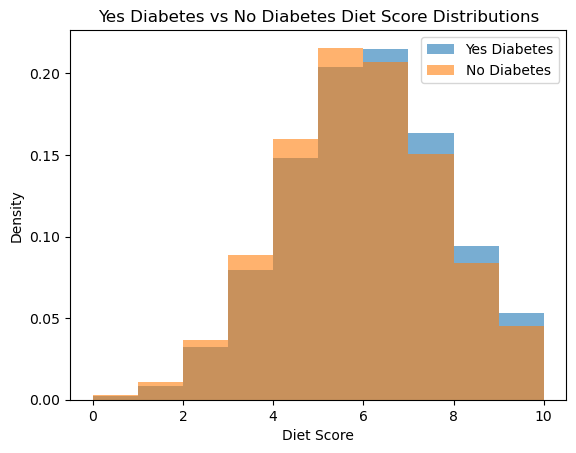

In [ ]:
df3s = list(df.groupby('diagnosed_diabetes')[['diet_score']])
# display(df3s)

yes_diabetes = df3s[0][1]
no_diabetes = df3s[1][1]

# 2-sample t-test
# mu1 < mu2
# H0 = The mean diet score of people with diabetes is not significantly different from 
# people without diabetes
# HA = The mean diet score of people with diabetes is less than people without diabetes

# display(yes_diabetes.describe(), no_diabetes.describe())

# Calculate p-value 
result = stats.ttest_ind(yes_diabetes['diet_score'], no_diabetes['diet_score'], alternative='less')

print(result.pvalue)

plt.hist(yes_diabetes, density=True, alpha=0.6, label="Yes Diabetes")
plt.hist(no_diabetes, density=True, alpha=0.6, label="No Diabetes")
plt.legend()
plt.title("Yes Diabetes vs No Diabetes Diet Score Distributions")
plt.xlabel("Diet Score")
plt.ylabel("Density")
plt.show()



Since our p-value is 1, which is greater than our α = 0.05, we fail to reject the null hypothesis and conclude that diabetes has no significant effect on someone’s mean diet score.